In [ ]:
#  ============================================================
# NOTEBOOK 01 - CONVERTIDOR BUCK-BOOST
# Grado de Electrónica - Electrónica de Potencia
# Septiembre/2026 (c)
#
# Objetivos:
#   1. Analizar el convertidor Buck-Boost inversor en CCM
#   2. Relacionar las corrientes del inductor y del condensador
#   3. Obtener las expresiones de Vout, Iout y los rizados
#   4. Comparar teoría, simulación numérica en Python y ngspice
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import os

# Configuración de gráficos
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


# **El convertidor Buck-Boost**

Un **convertidor Buck-Boost inversor** permite obtener una tensión continua de salida cuya magnitud puede ser menor o mayor que la tensión de entrada. En conducción continua (CCM) y para componentes ideales, $V_{out}=-\frac{D}{1-D}V_{in}$ El signo negativo indica que la polaridad de la salida es inversa respecto de la entrada. El ciclo de trabajo se define como $D=\frac{T_{ON}}{T},
$ donde $T$ es el periodo de conmutación, $T_{ON}=DT$ y $T_{OFF}=(1-D)T$ son los intervalos durante los cuales el interruptor permanece cerrado (ON) y abierto (OFF), respectivamente.

Los elementos fundamentales del **convertidor Buck-Boost** son:

* **Interruptor.** Conecta el nodo del inductor a masa durante el intervalo ON.

* **Diodo.** Permite transferir la energía almacenada en el inductor hacia la salida durante el intervalo OFF.

* **Inductor.** Almacena energía y se opone a cambios bruscos de corriente,
$v_L=L\frac{di_L}{dt}$.

* **Condensador.** Almacena energía y se opone a cambios bruscos de tensión,
$i_C=C\frac{dv_C}{dt}$, suavizando la tensión de salida.

* **Resistor.** Representa la carga.

En la topología inversora, la salida se toma con polaridad negativa respecto de masa.


* Cuando el interruptor está cerrado la tensión aplicada al inductor es $v_L=V_{in}$ y como $v_L=L\frac{di_L}{dt}$ tenemos:

$$
\boxed{
\frac{di_L}{dt}
=
\frac{V_{in}}{L}
}
$$

> Durante ON, la corriente del inductor aumenta linealmente y el inductor almacena energía.

* Cuando el interruptor está **abierto (OFF)**, el inductor entrega la energía almacenada a la salida a través del diodo. La tensión sobre el inductor es $v_L=-V_{out}.$ Por tanto,

$$
\boxed{
\frac{di_L}{dt}
=
-\frac{V_{out}}{L}
}
$$

y, puesto que $V_{out}<0$, la corriente del inductor disminuye linealmente.



# Corriente en el inductor

En **PSS**, la corriente del inductor comienza cada periodo con el mismo valor con el que terminó el periodo anterior, por lo que el cambio neto durante un periodo completo es cero.

* Durante el intervalo ON:

$$
\Delta i_{L,ON}
=
\frac{V_{in}}{L}DT
$$

* Durante el intervalo OFF:

$$
\Delta i_{L,OFF}
=
-\frac{V_{out}}{L}(1-D)T
$$

En régimen estacionario, $\Delta i_{L,ON}+\Delta i_{L,OFF}=0$ por lo que

$$
\frac{V_{in}}{L}DT-
\frac{V_{out}}{L}(1-D)T=0.
$$

Después de simplificar:

$$
\boxed{
V_{out}=\frac{D}{1-D}V_{in}
}
$$

El rizado de corriente del inductor es $\Delta i_L=i_{L,max}-i_{L,min},$ y en CCM se cumple $I_{L,min}>0$. Para el Buck-Boost ideal, se desprecian las pérdidas en el convertidor, usando el balance de potencia ideal, $P_{in}=P_{out}$, por lo que $V_{in}I_{in}=V_{out}I_{out},$ de donde $I_{out}=\frac{1-D}{D}I_{in}$. Donde $I_{out}=|V_{out}|/R$ representa la magnitud de la corriente de carga.


# Corriente del condensador

En el convertidor Buck-Boost, el comportamiento de $i_C$ depende directamente del estado del interruptor.

* Durante el intervalo **ON**, el diodo está bloqueado y el condensador alimenta la carga. Si definimos $I_{out}=|V_{out}|/R$ como la magnitud de la corriente de carga,

$$
\boxed{
i_C=-I_{out}
}
$$

* Durante el intervalo **OFF**, el inductor transfiere energía hacia la salida. La corriente del condensador puede escribirse, usando la misma convención de corriente adoptada para el modelo temporal, como

$$
\boxed{
i_C=i_L-I_{out}
}
$$

En PSS, la corriente media del condensador debe ser cero:

$$
\langle i_C\rangle=0.
$$

Por ello, durante ON el condensador suministra la corriente de carga, mientras que durante OFF recibe la energía transferida por el inductor y recupera carga.

La forma de $i_C$ no es idéntica a la del Buck: durante ON es aproximadamente constante y negativa, mientras que durante OFF depende de la corriente triangular del inductor.


# Tensión en el condensador

La tensión de salida es la tensión del condensador y resulta de integrar la corriente que circula por él:

$$
\boxed{
v_{out}(t)
=
v_{out}(0)
+
\frac{1}{C}
\int_0^t i_C(\tau)\,d\tau
}
$$

En el convertidor Buck-Boost, el condensador está conectado en paralelo con la carga y la tensión de salida es negativa.

* Si $i_C>0$, la tensión se desplaza hacia valores más positivos: $\frac{dv_{out}}{dt}>0$


* Si $i_C<0$, la tensión se desplaza hacia valores más negativos: $\frac{dv_{out}}{dt}<0$

Durante el intervalo ON, $i_C\approx-I_{out}<0$, por lo que la tensión de salida se hace más negativa.

Durante el intervalo OFF, el inductor transfiere energía hacia la salida y el condensador recupera carga.

Por tanto, los máximos y mínimos de $v_{out}$ aparecen cuando la corriente del condensador cambia de signo.


## Ondulación de tensión del condensador

La ondulación de tensión puede relacionarse con la carga que entra o sale del condensador,$\Delta V_{out}=\frac{\Delta Q}{C}.$ Para una primera aproximación del Buck-Boost en CCM, durante el intervalo ON el diodo está bloqueado y el condensador suministra aproximadamente la corriente de carga, $i_C\approx-I_{out}.$ La magnitud de la carga que pierde el condensador durante $T_{ON}=DT$ es entonces $\Delta Q\approx I_{out}DT.$ Por tanto, la magnitud de la ondulación es aproximadamente

$$
\boxed{
\Delta V_{out}
\approx
\frac{I_{out}D}{Cf}
}
$$

y usando $I_{out}=|V_{out}|/R$:

$$
\boxed{
\Delta V_{out}
\approx
\frac{|V_{out}|D}{RCf}
}
$$

Estas expresiones son aproximadas: suponen un condensador ideal, CCM y una corriente de carga aproximadamente constante durante un periodo. Se desprecia la resistencia serie equivalente (ESR).

Como $V_{out}<0$, en las gráficas se debe distinguir entre el valor medio negativo de $v_{out}$ y la magnitud positiva de su ondulación.


# Ejemplo. Considerar un **convertidor Buck-Boost** con $V_{in}=24\,V$, $D=1/3$, $T=10\,\mu s$, $L=26.7\,\mu H$, $C=69\,\mu F$ y $R=1.2\,\Omega$. Los tiempos durante los que el interruptor está cerrado y abierto son $T_{ON}=DT=3.33\,\mu s,$ $T_{OFF}=(1-D)T=6.67\,\mu s,$ respectivamente, con $f=\frac{1}{T}=100\,kHz.$

In [ ]:
# Parámetros del convertidor Buck-Boost
Vin         = 24.0          # V
D           = 1/3          # Duty cycle
Tsw         = 10e-6         # s
fs          = 1 / Tsw       # Hz

L           = 26.7e-6       # H
C           = 69e-6         # F
R           = 1.2           # ohm

Ton         = D * Tsw
Toff        = (1 - D) * Tsw

In [ ]:
# Impresión de parámetros
print(f"Vin  = {Vin:.2f} V")
print(f"D    = {D:.2f}")
print(f"fs   = {fs/1e3:.1f} kHz")
print(f"Ton  = {Ton*1e6:.2f} us")
print(f"Toff = {Toff*1e6:.2f} us")
print(f"L    = {L*1e6:.1f} uH")
print(f"C    = {C*1e6:.1f} uF")
print(f"R    = {R:.1f} ohm")


Vin  = 24.00 V
D    = 0.33
fs   = 100.0 kHz
Ton  = 3.33 us
Toff = 6.67 us
L    = 26.7 uH
C    = 69.0 uF
R    = 1.2 ohm


In [ ]:
# Resultados teóricos del Buck-Boost ideal, Vout/Iout
Vout_ideal = D / (1 - D) * Vin
Iout_ideal = Vout_ideal / R

# Corriente media del inductor.
I_L_avg =  Iout_ideal / (1 - D)

# Ripple de corriente del inductor.
delta_iL = Vin * Ton / L

I_L_min = I_L_avg - delta_iL / 2
I_L_max = I_L_avg + delta_iL / 2

# Ripple de tensión del condensador (magnitud).
delta_Vout = Iout_ideal * D / (fs * C)


In [ ]:
print("===== RESULTADOS TEÓRICOS =====")
print(f"Vout medio       = {Vout_ideal:.4f} V")
print(f"Iout medio       = {Iout_ideal:.4f} A")
print(f"IL medio         = {I_L_avg:.4f} A")
print(f"Delta iL         = {delta_iL:.4f} A")
print(f"I_L mínimo       = {I_L_min:.4f} A")
print(f"I_L máximo       = {I_L_max:.4f} A")
print(f"Delta |Vout| aprox = {delta_Vout:.4f} V")


===== RESULTADOS TEÓRICOS =====
Vout medio       = 12.0000 V
Iout medio       = 10.0000 A
IL medio         = 15.0000 A
Delta iL         = 2.9963 A
I_L mínimo       = 13.5019 A
I_L máximo       = 16.4981 A
Delta |Vout| aprox = 0.4831 V


In [ ]:
# Analizar un periodo en PSS
# Tiempo
t = np.linspace(0, Tsw, 1000)
# Corriente del inductor
iL = np.zeros_like(t)

# ON: la corriente aumenta
mask_on = t < Ton
iL[mask_on] = I_L_min + (delta_iL / Ton) * t[mask_on]

# OFF: la corriente disminuye
t_off = t[~mask_on] - Ton
iL[~mask_on] = I_L_max - (delta_iL / Toff) * t_off

# Corriente del condensador.
# Iout_ideal se define como magnitud positiva de la carga.
iC = np.where(mask_on, -Iout_ideal, iL - Iout_ideal)

# Integración de la corriente del condensador
dt = t[1] - t[0]
v_ripple = np.cumsum(iC) * dt / C

# Centrar el ripple alrededor de cero
v_ripple -= np.mean(v_ripple)

# Vout es negativa
vout_t = Vout_ideal + v_ripple

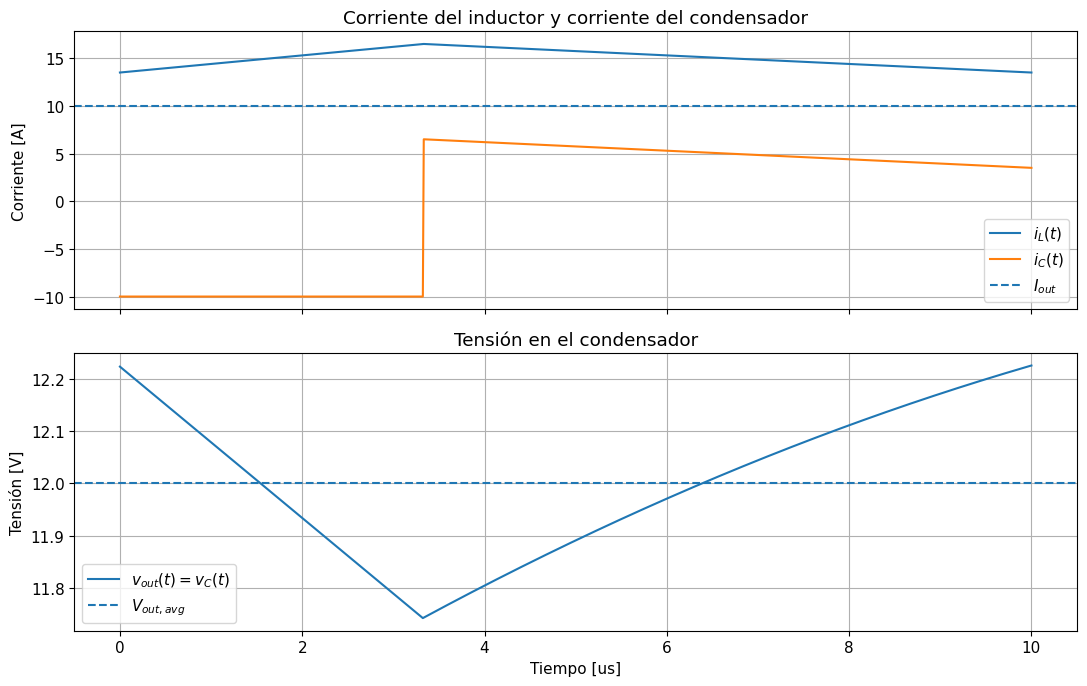

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Corrientes
ax[0].plot(t * 1e6, iL, label=r"$i_L(t)$")
ax[0].plot(t * 1e6, iC, label=r"$i_C(t)$")
ax[0].axhline(Iout_ideal, linestyle="--", label=r"$I_{out}$")

ax[0].set_ylabel("Corriente [A]")
ax[0].set_title("Corriente del inductor y corriente del condensador")
ax[0].grid(True)
ax[0].legend()

# Tensión
ax[1].plot(t * 1e6, vout_t, label=r"$v_{out}(t)=v_C(t)$")
ax[1].axhline(Vout_ideal, linestyle="--", label=r"$V_{out,avg}$")

ax[1].set_xlabel("Tiempo [us]")
ax[1].set_ylabel("Tensión [V]")
ax[1].set_title("Tensión en el condensador")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


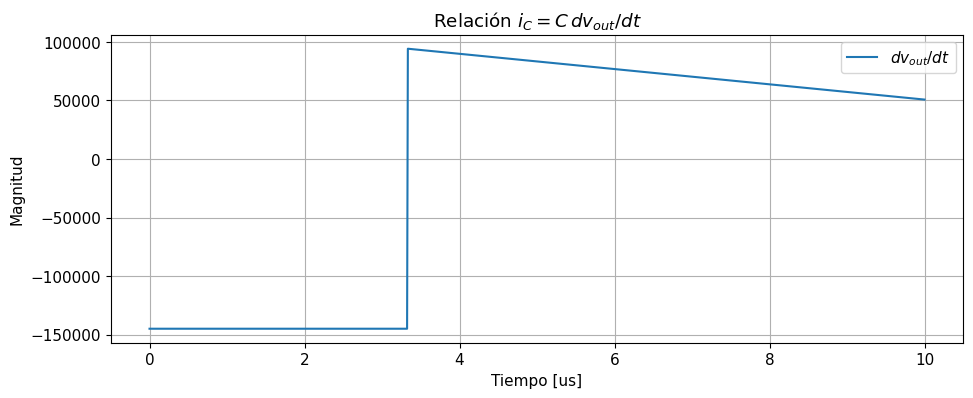

In [ ]:
# Verificación directa: iC = C * dvout/dt

dvout_dt = iC / C

plt.figure(figsize=(11, 4))
plt.plot(t * 1e6, dvout_dt, label=r"$dv_{out}/dt$")

plt.xlabel("Tiempo [us]")
plt.ylabel("Magnitud")
plt.title(r"Relación $i_C=C\,dv_{out}/dt$")
plt.grid(True)
plt.legend()

plt.show()


In [ ]:
# Simulación numérica del Buck-Boost ideal

t_stop = 2e-3
dt = 0.2e-6

t = np.arange(0, t_stop + dt, dt)

iL = np.zeros_like(t)
vout = np.zeros_like(t)
gate = np.zeros_like(t)

for k in range(len(t) - 1):
    # Estado del interruptor
    on = (t[k] % Tsw) < Ton
    gate[k] = 1 if on else 0

    # Ecuación del inductor
    if on:
        # Switch cerrado: el nodo del inductor está a masa
        di_dt = Vin / L
    else:
        # Switch abierto: el inductor queda conectado a la salida negativa
        di_dt = -vout[k] / L

    # Ecuación del condensador
    # Durante ON el condensador alimenta la carga.
    # Durante OFF el inductor transfiere energía a la salida.
    if on:
        iC_k = -abs(vout[k]) / R
    else:
        iC_k = iL[k] - abs(vout[k]) / R

    # Integración Euler
    iL[k+1] = iL[k] + di_dt * dt
    vout[k+1] = vout[k] + (iC_k / C) * dt

gate[-1] = gate[-2]


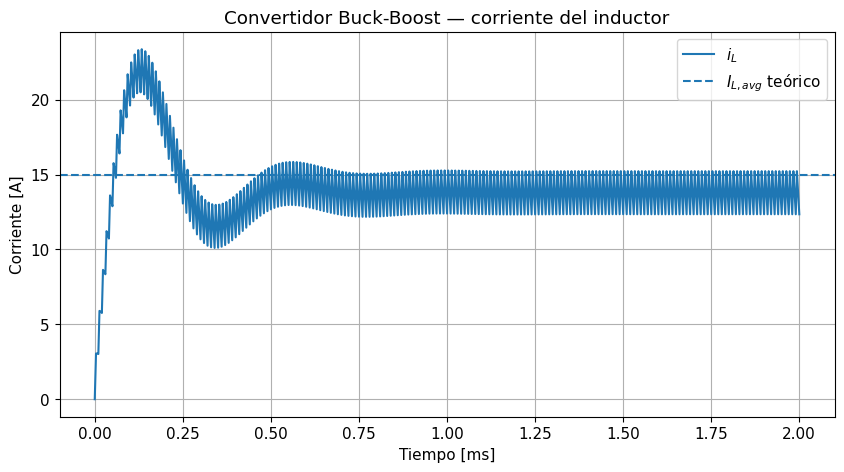

In [ ]:
plt.plot(t * 1e3, iL, label=r"$i_L$")
plt.axhline(I_L_avg, linestyle="--", label=r"$I_{L,avg}$ teórico")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Corriente [A]")
plt.title("Convertidor Buck-Boost — corriente del inductor")
plt.grid(True)
plt.legend()
plt.show()


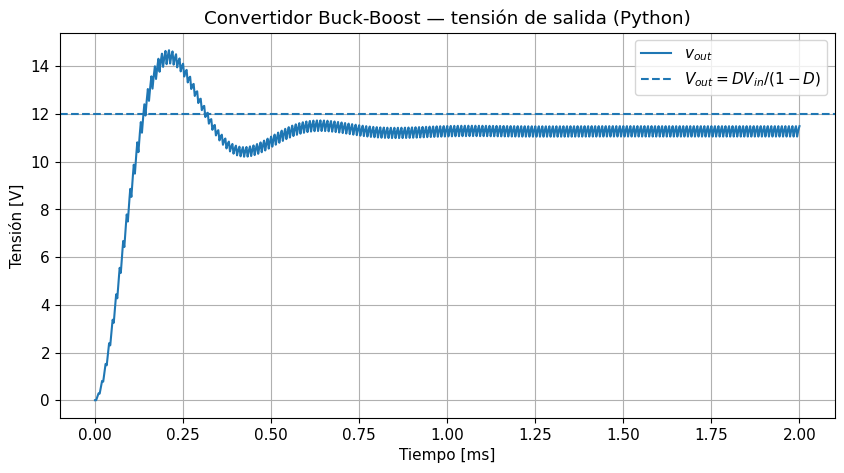

In [ ]:
plt.plot(t * 1e3, vout, label=r"$v_{out}$")
plt.axhline(Vout_ideal, linestyle="--", label=r"$V_{out}=DV_{in}/(1-D)$")

plt.xlabel("Tiempo [ms]")
plt.ylabel("Tensión [V]")
plt.title("Convertidor Buck-Boost — tensión de salida (Python)")
plt.grid(True)
plt.legend()
plt.show()


# **Simulación SPICE**

In [ ]:
# Instalar ngspice para linux dentro del entorno COLAB
!apt-get update -qq
!apt-get install -y ngspice


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ngspice is already the newest version (36+ds-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 22 not upgraded.


In [ ]:
# Comprobar la instalación solicitando la versión ngspice instalada
!ngspice -v


******
** ngspice-36 : Circuit level simulation program
** The U. C. Berkeley CAD Group
** Copyright 1985-1994, Regents of the University of California.
** Copyright 2001-2020, The ngspice team.
** Please get your ngspice manual from http://ngspice.sourceforge.net/docs.html
** Please file your bug-reports at http://ngspice.sourceforge.net/bugrep.html
** Creation Date: Mon Mar 11 21:44:53 UTC 2024
******


In [ ]:
netlist_buck_boost = r'''
* ============================================================
* CONVERTIDOR BUCK-BOOST IDEAL
* ============================================================

.title Buck-Boost converter - ideal switch

* Parámetros
.param Vinval = 24
.param Rval   = 1.2
.param Lval   = 26.7u
.param Cval   = 69u

.param Tsw    = 10u
.param Duty   = 0.3333

* Fuente de entrada
V1 in 0 DC {Vinval}
* Señal de control
Vgate gate 0 PULSE(0 5 0 10n 10n {Duty*Tsw} {Tsw})
* Inductor
L1 sw 0 {Lval}
* Interruptor: nodo in -> sw cuando ON
S1 in sw gate 0 SWMOD
* Diodo: ánodo en out, cátodo en sw
D1 out sw DIDEAL
* Carga
R1 out 0 {Rval}
* Condensador de salida
C1 out 0 {Cval}
* Modelos
.model DIDEAL D(IS=1e-15 N=0.01 RS=1m BV=100)
.model SWMOD SW(RON=1m ROFF=1Meg VT=2 VH=0.1)

* Análisis transitorio
.tran 0.1u 2m

.control
run
set filetype=ascii
wrdata buck_boost_results.txt time v(out) i(L1)
.endc

.end
'''


In [ ]:
# Crear netlist
with open("buck_boost.sp", "w") as f:
    f.write(netlist_buck_boost)

print("Netlist creado: buck_boost.sp")


Netlist creado: buck_boost.sp


In [ ]:
# Ejecutar ngspice
result = subprocess.run(
    ["ngspice", "-b", "buck_boost.sp"],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("Mensajes:")
    print(result.stderr)

print("Código de salida:", result.returncode)

if result.returncode == 0:
    print("Simulación completada correctamente.")



No compatibility mode selected!


Circuit: Buck-Boost converter - ideal switch

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
in                                          24
gate                                         0
sw                                           0
out                                1.24496e-26
l1#branch                              2.4e-05
vgate#branch                                 0
v1#branch                             -2.4e-05


No. of Data Rows : 28207

Mensajes:
Note: No ".plot", ".print", or ".fourier" lines; no simulations run

Código de salida: 1


In [ ]:
data = pd.read_csv(
    "buck_boost_results.txt",
    sep=r"\s+",
    engine="python",
    header=None
)

data.head()


,0,1,2,3,4,5
0,0.000000e+00,0.000000e+00,0.000000e+00,1.244959e-26,0.000000e+00,0.000024
1,1.000000e-10,1.000000e-10,1.000000e-10,1.244957e-26,1.000000e-10,0.000024
2,2.000000e-10,2.000000e-10,2.000000e-10,1.244956e-26,2.000000e-10,0.000024
3,4.000000e-10,4.000000e-10,4.000000e-10,1.244955e-26,4.000000e-10,0.000024
4,8.000000e-10,8.000000e-10,8.000000e-10,1.244951e-26,8.000000e-10,0.000024


In [ ]:
data.columns = ["time", "NADA1", "NADA2", "vout", "NADA3", "iL"]
data.tail()


,time,NADA1,NADA2,vout,NADA3,iL
28202,0.002,0.002,0.002,-12.228938,0.002,13.693685
28203,0.002,0.002,0.002,-12.233979,0.002,13.647787
28204,0.002,0.002,0.002,-12.238946,0.002,13.601871
28205,0.002,0.002,0.002,-12.243842,0.002,13.555936
28206,0.002,0.002,0.002,-12.245337,0.002,13.541759


In [ ]:
# Comparación entre teoría y simulación
# Utilizamos solamente el último 20 % de la simulación
# para representar el régimen estacionario.

mask = data["time"] > 0.8 * data["time"].max()

vout_avg_sim = data.loc[mask, "vout"].mean()
iL_avg_sim = data.loc[mask, "iL"].mean()

iL_min_sim = data.loc[mask, "iL"].min()
iL_max_sim = data.loc[mask, "iL"].max()

vout_min_sim = data.loc[mask, "vout"].min()
vout_max_sim = data.loc[mask, "vout"].max()

delta_vout_sim = vout_max_sim - vout_min_sim
delta_vout_mag_sim = abs(delta_vout_sim)


In [ ]:
print("========== TEORÍA ==========")
print(f"Vout = {Vout_ideal:.4f} V")
print(f"|Vout| = {abs(Vout_ideal):.4f} V")
print(f"Iout = {Iout_ideal:.4f} A")
print(f"IL medio = {I_L_avg:.4f} A")
print(f"Delta iL = {delta_iL:.4f} A")
print(f"Delta |Vout| aprox = {delta_Vout:.4f} V")

print("\n======= NGSPICE =======")
print(f"Vout medio = {vout_avg_sim:.4f} V")
print(f"IL medio   = {iL_avg_sim:.4f} A")
print(f"IL mínimo  = {iL_min_sim:.4f} A")
print(f"IL máximo  = {iL_max_sim:.4f} A")
print(f"Delta iL   = {iL_max_sim-iL_min_sim:.4f} A")
print(f"Vout min   = {vout_min_sim:.4f} V")
print(f"Vout max   = {vout_max_sim:.4f} V")
print(f"Delta Vout = {delta_vout_sim:.4f} V")
print(f"Delta |Vout| = {delta_vout_mag_sim:.4f} V")


========== TEORÍA ==========
Vout = 12.0000 V
|Vout| = 12.0000 V
Iout = 10.0000 A
IL medio = 15.0000 A
Delta iL = 2.9963 A
Delta |Vout| aprox = 0.4831 V

======= NGSPICE =======
Vout medio = -12.0171 V
IL medio   = 15.0372 A
IL mínimo  = 13.5390 A
IL máximo  = 16.5447 A
Delta iL   = 3.0057 A
Vout min   = -12.2462 V
Vout max   = -11.7604 V
Delta Vout = 0.4858 V
Delta |Vout| = 0.4858 V


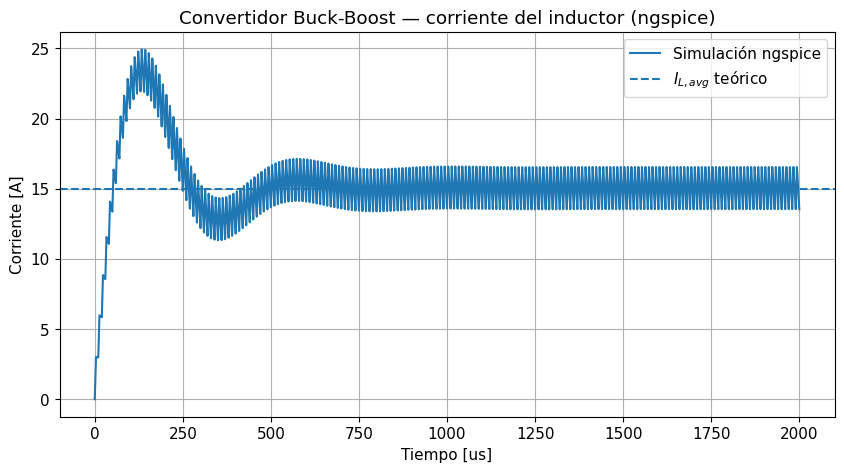

In [ ]:
plt.plot(data["time"] * 1e6, data["iL"], label="Simulación ngspice")
plt.axhline(I_L_avg, linestyle="--", label=r"$I_{L,avg}$ teórico")

plt.xlabel("Tiempo [us]")
plt.ylabel("Corriente [A]")
plt.title("Convertidor Buck-Boost — corriente del inductor (ngspice)")
plt.grid(True)
plt.legend()
plt.show()


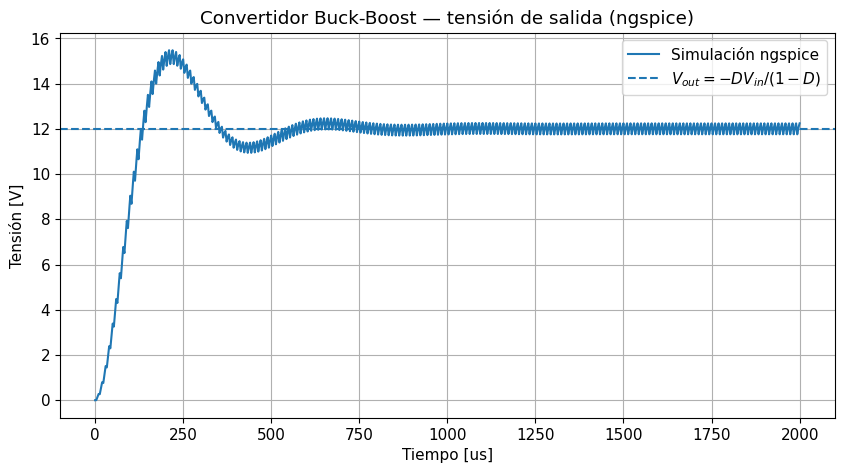

In [ ]:
plt.plot(data["time"] * 1e6, -data["vout"], label="Simulación ngspice")
plt.axhline(Vout_ideal, linestyle="--",    label=r"$V_{out}=-DV_{in}/(1-D)$")

plt.xlabel("Tiempo [us]")
plt.ylabel("Tensión [V]")
plt.title("Convertidor Buck-Boost — tensión de salida (ngspice)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# Construcción del modelo triangular teórico de iL

# Elegimos un periodo situado en régimen estacionario
T0 = 1.8e-3
T1 = T0 + Tsw

mask_period = ((t >= T0) & (t <= T1))

t_period = t[mask_period]
i_period = iL[mask_period]


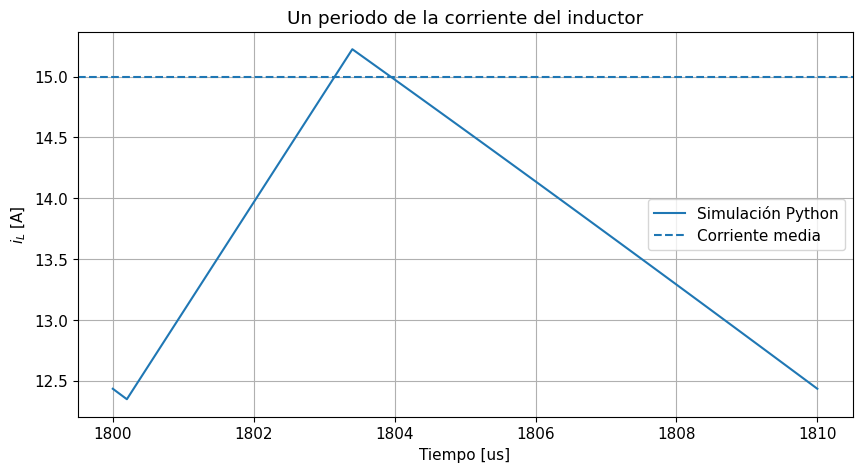

In [ ]:
plt.plot(t_period * 1e6, i_period, label="Simulación Python")

plt.axhline(I_L_avg, linestyle="--", label="Corriente media")

plt.xlabel("Tiempo [us]")
plt.ylabel(r"$i_L$ [A]")
plt.title("Un periodo de la corriente del inductor")
plt.grid(True)
plt.legend()

plt.show()
